## Assignment 3 - Visualization made in Python

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the data
path = "/Users/celinecuinat/DSI/visualization/02_activities/assignments/overall_kpi_report_2023_raw_data.csv"
df = pd.read_csv(path)
#df.head()

In [ ]:
# Remove rows where Program Type is empty
df = df[df["Program Type"].notna()]
df = df[df["Program Type"].str.strip() != ""]
#df.head()

In [4]:
#Clean the columns of interest: graduation and graduate employment rate (they have ND, SS values, etc. that we cannot use)
numeric_cols = [
    "GRADUATION RATE\n(%)",
    "GRADUATE EMPLOYMENT RATE\n(%)"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_clean = df.dropna(subset=numeric_cols)

In [5]:
#Get variables aggregated by program type
plot_df = (
    df_clean
    .groupby("Program Type", as_index=False)[numeric_cols]
    .mean()
)

#Mulitply by 100 to get % (got lost when converting to csv)
plot_df[numeric_cols] = plot_df[numeric_cols] * 100

#plot_df

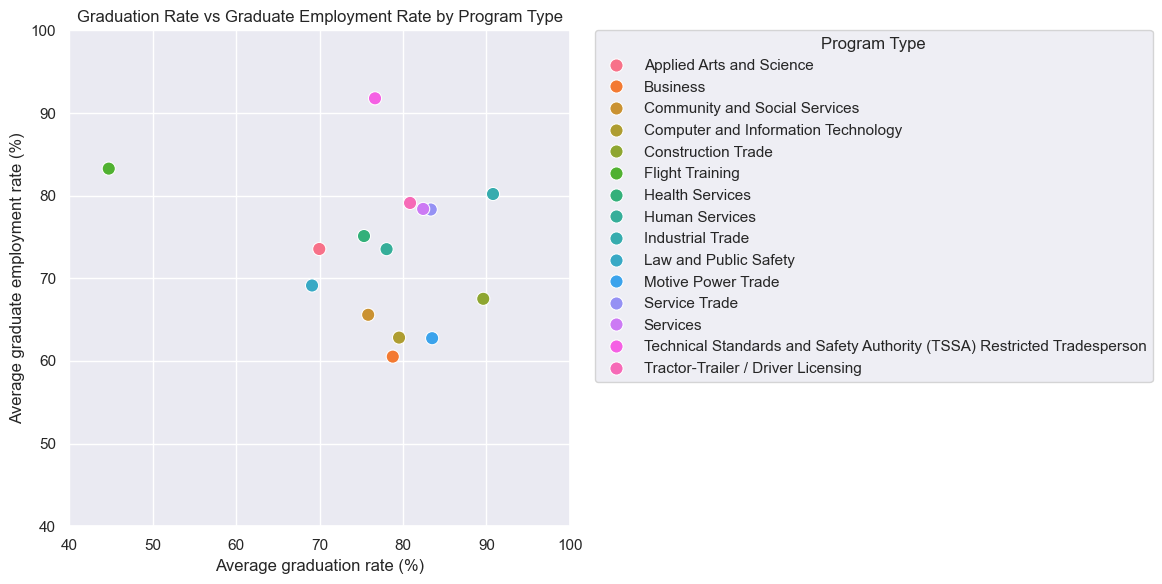

In [6]:
#Use seaborn color theme (color-blind friendly)
sns.set_theme(style="darkgrid", palette="colorblind")

#Create a scatter plot of graduate employment rate according to graduation rate, stratified by program type
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=plot_df,
    x="GRADUATION RATE\n(%)",
    y="GRADUATE EMPLOYMENT RATE\n(%)",
    hue="Program Type",
    s=90,
    ax=ax
)

#Improve the axis and titles
ax.set_xlim(40, 100) #otherwise all dots are clustered on the top right corner
ax.set_ylim(40, 100)
ax.set_xlabel("Average graduation rate (%)")
ax.set_ylabel("Average graduate employment rate (%)")
ax.set_title("Graduation Rate vs Graduate Employment Rate by Program Type")

#Add a legend of program type colors
ax.legend(
    title="Program Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout() 

#Export the plot
plt.savefig("graduation_vs_employment_program_type.png", dpi=300, bbox_inches="tight")

